In [12]:
import numpy as np
import sys
import os
import VBMicrolensing
import emcee
import h5py
import math
import matplotlib.pyplot as plt
import concurrent.futures
import corner
from tqdm import tqdm
VBM = VBMicrolensing.VBMicrolensing()
JD0 = 2450000
from matplotlib.lines import Line2D
sys.path.append("/moao38_7/nunota/genulens/genprior/gentool/")
from gapmoe import gapmoe
gapmoe_model = gapmoe(rhos_path="/moao38_7/nunota/genulens/genprior/test_data/riron_ns.dat",
                      mass_path="/moao38_7/nunota/binfit/work/MB23162/tool/check_Mhist.dat",
                      mu_path="/moao38_7/nunota/genulens/genprior/test_data/murel_hist.dat")
gapmoe_model.set_data(fREM_range=[0])

from matplotlib.ticker import AutoMinorLocator

In [2]:
column_names = " wtj          M_L   D_L   D_S          t_E      theta_E         pi_E         pi_EN         pi_EE       mu_rel        mu_Sl        mu_Sb     I_L iS iL fREM".strip().split()

path_prior = "../test_gal_result/genout_prior.dat"
data_gal_prior = np.genfromtxt(path_prior, names=column_names)

# flat prior の μ
data_gal_muN = data_gal_prior["mu_rel"] * np.cos(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
data_gal_muE = data_gal_prior["mu_rel"] * np.sin(np.arctan2(data_gal_prior["pi_EE"], data_gal_prior["pi_EN"]))
mu_tot_flat = np.sqrt(data_gal_muN**2 + data_gal_muE**2)
mask_flat = mu_tot_flat < 20

In [3]:
non_uni_prior = np.load("../test_data/non_uniform_prior.npy")

non_uni_prior_ML =non_uni_prior[:, 2]
non_uni_prior_DL = non_uni_prior[:, 3]
non_uni_prior_Ds = non_uni_prior[:, 4]
non_uni_prior_muN = non_uni_prior[:, 0]
non_uni_prior_muE = non_uni_prior[:, 1]

valid_mask = (non_uni_prior_DL > 0) & (non_uni_prior_Ds > 0)

non_uni_prior_ML = non_uni_prior[valid_mask, 2]
non_uni_prior_DL = non_uni_prior[valid_mask, 3]
non_uni_prior_Ds = non_uni_prior[valid_mask, 4]
non_uni_prior_muN = non_uni_prior[valid_mask, 0]
non_uni_prior_muE = non_uni_prior[valid_mask, 1]

mu_tot_nonuni = np.sqrt(non_uni_prior_muN**2 + non_uni_prior_muE**2)
mask_nonuni = mu_tot_nonuni < 20

In [4]:
flat_prior_data_log = np.vstack([
    np.log10(data_gal_prior["M_L"][mask_flat]),
    data_gal_prior["D_L"][mask_flat] * 1e-3,
    data_gal_prior["D_S"][mask_flat] * 1e-3,
    data_gal_muN[mask_flat],
    data_gal_muE[mask_flat]
]).T

nonuni_prior_data_log = np.vstack([
    np.log10(non_uni_prior_ML[mask_nonuni]),
    non_uni_prior_DL[mask_nonuni],
    non_uni_prior_Ds[mask_nonuni],
    non_uni_prior_muN[mask_nonuni],
    non_uni_prior_muE[mask_nonuni]
]).T

In [5]:
labels_5d_log = [
    r"$\log_{10}(M_{\rm L}/M_\odot)$",
    r"$D_{\rm L}\ [{\rm kpc}]$",
    r"$D_{\rm S}\ [{\rm kpc}]$",
    r"$\mu_{\rm N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm E}\ [{\rm mas/yr}]$"
]

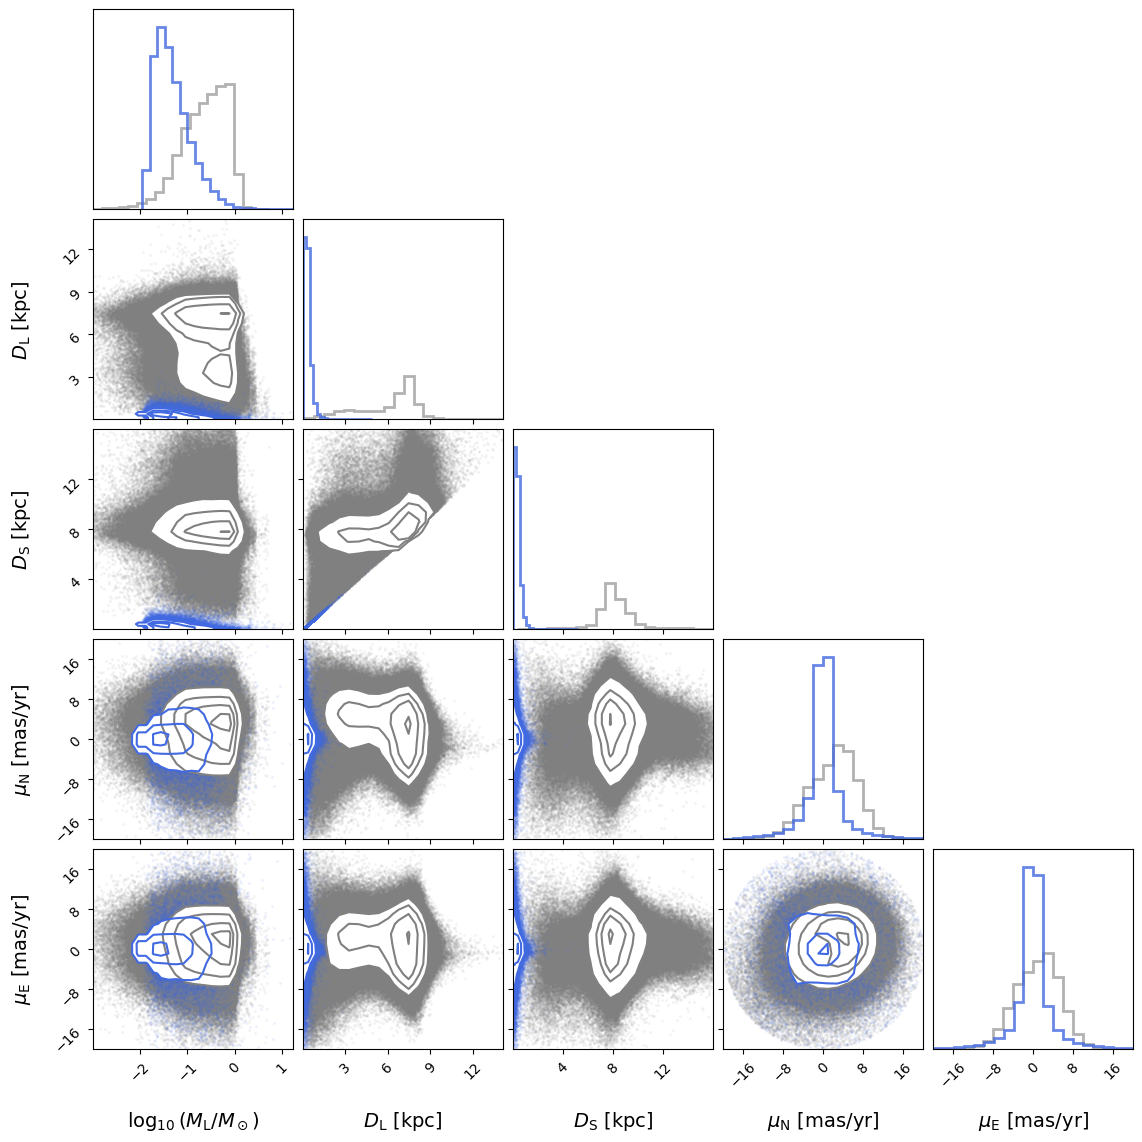

In [6]:
fig = corner.corner(
    flat_prior_data_log,
    labels=labels_5d_log,
    color="gray",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.6},
    label_kwargs={"fontsize": 14},
    show_titles=False,
    plot_density=False
)

corner.corner(
    nonuni_prior_data_log,
    fig=fig,
    color="royalblue",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8},
    plot_density=False
)

plt.show()

In [7]:
flat_prior_log_data = np.vstack([
    np.log10(data_gal_prior["M_L"][mask_flat]),
    np.log10(data_gal_prior["D_L"][mask_flat] * 1e-3),
    np.log10(data_gal_prior["D_S"][mask_flat] * 1e-3),
    data_gal_muN[mask_flat],
    data_gal_muE[mask_flat]
]).T

nonuni_prior_log_data = np.vstack([
    np.log10(non_uni_prior_ML[mask_nonuni]),
    np.log10(non_uni_prior_DL[mask_nonuni]),
    np.log10(non_uni_prior_Ds[mask_nonuni]),
    non_uni_prior_muN[mask_nonuni],
    non_uni_prior_muE[mask_nonuni]
]).T

In [8]:
labels_log = [
    r"$\log_{10}(M_{\rm L}/M_\odot)$",
    r"$\log_{10}(D_{\rm L}/{\rm kpc})$",
    r"$\log_{10}(D_{\rm S}/{\rm kpc})$",
    r"$\mu_{\rm N}\ [{\rm mas/yr}]$",
    r"$\mu_{\rm E}\ [{\rm mas/yr}]$"
]

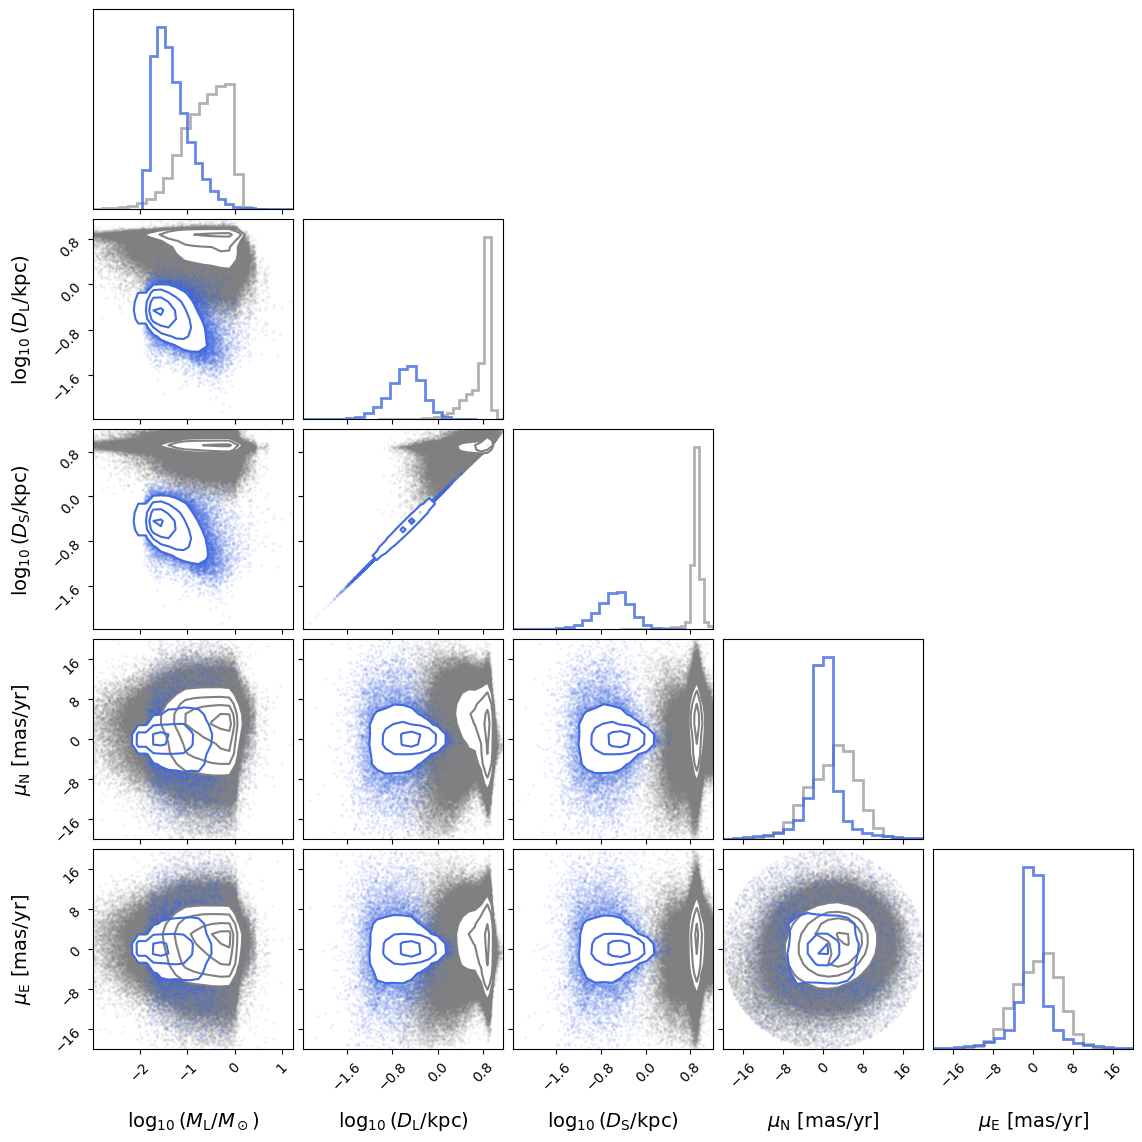

In [9]:
fig = corner.corner(
    flat_prior_log_data,
    labels=labels_log,
    color="gray",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.6},
    label_kwargs={"fontsize": 14},
    show_titles=False,
    plot_density=False
)

corner.corner(
    nonuni_prior_log_data,
    fig=fig,
    color="royalblue",
    hist_kwargs={"density": True, "linewidth": 2, "alpha": 0.8},
    plot_density=False
)


plt.show()

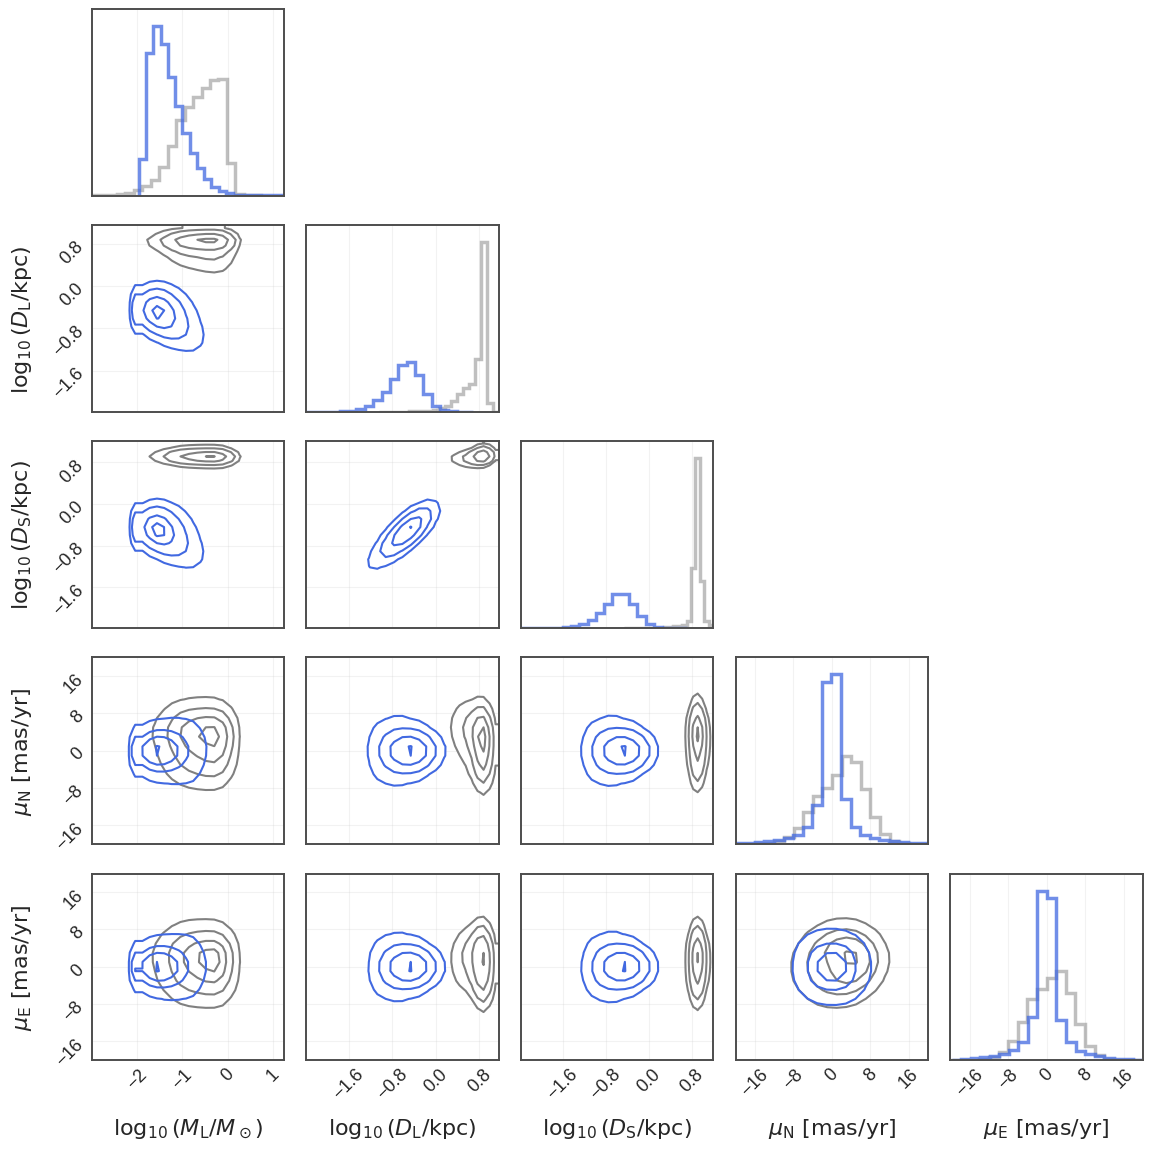

In [17]:


# --- スタイル設定（seaborn風 + カスタム） ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

# --- corner plot 本体 ---
fig = corner.corner(
    flat_prior_log_data,
    labels=labels_log,
    color="gray",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 0.5},
    label_kwargs={"fontsize": 16},
    show_titles=False,
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
)

corner.corner(
    nonuni_prior_log_data,
    fig=fig,
    color="royalblue",
    hist_kwargs={"density": True, "linewidth": 2.5, "alpha": 0.75},
    plot_density=False,
    plot_datapoints=False,
    smooth=1.0,
)

# --- 保存と表示 ---
plt.tight_layout()
plt.show()